# Proyecto Final de Procesamiento de Lenguaje Natural

## Sistema inteligente para el análisis de la voz del cliente en reseñas de productos

**Dataset:** `KRadim/edit_amazon_reviews_multi_es`  
**Idioma:** español  
**Caso de uso:** Voz del cliente en comercio electrónico

### Objetivo general

Construir un sistema de Procesamiento de Lenguaje Natural capaz de:

- limpiar y preparar reseñas de productos en español;
- representar los textos mediante Bag of Words, TF-IDF y embeddings;
- descubrir los principales temas del corpus con LDA;
- clasificar el sentimiento con Naive Bayes y LSTM;
- comparar ambos modelos mediante métricas;
- detectar aspectos como precio, calidad, entrega, empaque y funcionamiento;
- ofrecer una interfaz funcional en Gradio.

---

## División del notebook

### PARTE A — Entrenamiento y guardado de modelos

Incluye:

1. Presentación del proyecto  
2. Importación de librerías  
3. Descarga del dataset  
4. Exploración de datos  
5. Preprocesamiento  
6. Representación del texto  
7. Modelado de temas  
8. Naive Bayes  
9. LSTM  
10. Comparación  
11. Detección de aspectos  
12. Guardado de modelos  

### PARTE B — Carga de modelos, Gradio y demo

Permite abrir la aplicación sin volver a entrenar los modelos.


# PARTE A — ENTRENAMIENTO Y GUARDADO DE MODELOS

## 1. Presentación del proyecto

Las empresas de comercio electrónico reciben una gran cantidad de reseñas. Revisarlas manualmente dificulta identificar rápidamente:

- si el cliente está satisfecho;
- qué aspectos generan reclamos;
- cuáles son los principales temas de conversación;
- qué diferencias existen entre los modelos de clasificación.

El sistema utilizará las estrellas para construir tres etiquetas:

| Estrellas | Sentimiento |
|---:|---|
| 1–2 | Negativo |
| 3 | Neutro |
| 4–5 | Positivo |

La interfaz recibirá una nueva reseña y mostrará:

- sentimiento predicho por Naive Bayes;
- sentimiento predicho por LSTM;
- probabilidades de cada clase;
- tema LDA;
- aspectos detectados;
- texto preprocesado.

## 2. Importación de librerías

In [ ]:
# ============================================================
# 2. INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# Instalamos las librerías que podrían no estar disponibles en Colab.
!pip -q install datasets gradio gensim unidecode

# Librerías generales.
import os
import re
import json
import random
import warnings
from pathlib import Path

# Datos y visualización.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PLN y descarga del dataset.
import joblib
from unidecode import unidecode
from datasets import load_dataset
from gensim.models import Word2Vec

# Machine Learning.
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay
)

# Deep Learning.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Interfaz.
import gradio as gr

warnings.filterwarnings("ignore")

# Semillas para reproducibilidad.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 10.2 MB/s eta 0:00:00
TensorFlow: 2.20.0
GPU disponible: []


### Configuración de Google Drive

Los modelos y resultados se guardarán en Google Drive para evitar perderlos cuando Colab cierre la sesión.

In [ ]:
# ============================================================
# CONFIGURACIÓN DE GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/Proyecto_PLN_Amazon")
MODELS_DIR = PROJECT_DIR / "modelos"
RESULTS_DIR = PROJECT_DIR / "resultados"
DATA_DIR = PROJECT_DIR / "datos"

for carpeta in [PROJECT_DIR, MODELS_DIR, RESULTS_DIR, DATA_DIR]:
    carpeta.mkdir(parents=True, exist_ok=True)

print("Carpeta principal:", PROJECT_DIR)

Mounted at /content/drive
Carpeta principal: /content/drive/MyDrive/Proyecto_PLN_Amazon


## 3. Descarga del dataset

El dataset se descarga directamente desde Hugging Face.

Contiene tres particiones:

- `train`;
- `validation`;
- `test`.

Columnas principales:

- `stars`;
- `review_body`;
- `review_title`;
- `language`;
- `product_category`.

Para que el entrenamiento sea viable en Google Colab, se utilizará una muestra balanceada configurable del conjunto de entrenamiento.

In [ ]:
# ============================================================
# 3. DESCARGA DEL DATASET
# ============================================================

DATASET_NAME = "KRadim/edit_amazon_reviews_multi_es"

# Descargamos el dataset.
dataset = load_dataset(DATASET_NAME)

print(dataset)
print("\nColumnas disponibles:")
print(dataset["train"].column_names)

README.md:   0%|          | 0.00/2.24k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/26.2M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/691k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/199500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5250 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'stars', 'review_body', 'review_title', 'language', 'product_category', 'lenght_review_body', 'lenght_review_title', 'lenght_product_category'],
        num_rows: 199500
    })
    validation: Dataset({
        features: ['id', 'stars', 'review_body', 'review_title', 'language', 'product_category', 'lenght_review_body', 'lenght_review_title', 'lenght_product_category'],
        num_rows: 5250
    })
    test: Dataset({
        features: ['id', 'stars', 'review_body', 'review_title', 'language', 'product_category', 'lenght_review_body', 'lenght_review_title', 'lenght_product_category'],
        num_rows: 5250
    })
})

Columnas disponibles:
['id', 'stars', 'review_body', 'review_title', 'language', 'product_category', 'lenght_review_body', 'lenght_review_title', 'lenght_product_category']


In [ ]:
# ============================================================
# CONVERSIÓN A DATAFRAME
# =============================================+===============

# Convertimos las tres particiones a pandas.
df_train_raw = dataset["train"].to_pandas()
df_val_raw = dataset["validation"].to_pandas()
df_test_raw = dataset["test"].to_pandas()

print("Train:", df_train_raw.shape)
print("Validation:", df_val_raw.shape)
print("Test:", df_test_raw.shape)

display(df_train_raw.head())

Train: (199500, 9)
Validation: (5250, 9)
Test: (5250, 9)


,id,stars,review_body,review_title,language,product_category,lenght_review_body,lenght_review_title,lenght_product_category
0,111516,1,No llegaron las hélices,Mal servicio,es,electronics,23,12,11
1,107084,4,Me encanta lo ligera y manejable que es. Plega...,Manejable y ligera,es,baby_product,420,18,12
2,199386,1,"De las dos baterias , hay una que no funciona",No comprare mas,es,home_improvement,45,15,16
3,69470,2,"la iluminación es genial, pero el adhesivo pos...",el adhesivo no pega bien,es,home,105,24,4
4,114836,4,La he comprado porque por estética y colores e...,Original,es,home,165,8,4


## 4. Exploración de datos (EDA)

In [ ]:
# ============================================================
# 4.1 REVISIÓN GENERAL
# ============================================================

print("\nTipos de datos:")
display(df_train_raw.dtypes.to_frame("tipo"))

print("\nValores faltantes:")
display(df_train_raw.isna().sum().to_frame("faltantes"))

print("\nDuplicados completos:", df_train_raw.duplicated().sum())
print("Duplicados por review_body:", df_train_raw["review_body"].duplicated().sum())

display(df_train_raw.sample(5, random_state=SEED))


Tipos de datos:


,tipo
id,uint32
stars,int64
review_body,object
review_title,object
language,object
product_category,object
lenght_review_body,uint32
lenght_review_title,uint32
lenght_product_category,uint32



Valores faltantes:


,faltantes
id,0
stars,0
review_body,0
review_title,0
language,0
product_category,0
lenght_review_body,0
lenght_review_title,0
lenght_product_category,0



Duplicados completos: 0
Duplicados por review_body: 1726


,id,stars,review_body,review_title,language,product_category,lenght_review_body,lenght_review_title,lenght_product_category
114485,137501,4,"Los protectores llegan en una cajita, envuelto...",Muy recomendable,es,wireless,537,16,8
82408,79163,3,El material está bien pero llegó pasada la tem...,Envio fatal,es,sports,79,11,6
105739,45371,4,"Por el precio que cuesta, está muy bien, llega...",Calidad precio buena.,es,home,68,21,4
171697,38338,5,Justo lo que buscaba. Calidad de 10. Bastante ...,EXCELENTE,es,home,78,9,4
182553,66731,1,La compré para proteger el objetivo de la cama...,No cumple su función,es,camera,155,20,6


,cantidad
stars,
1,39848
2,39901
3,39889
4,39935
5,39927


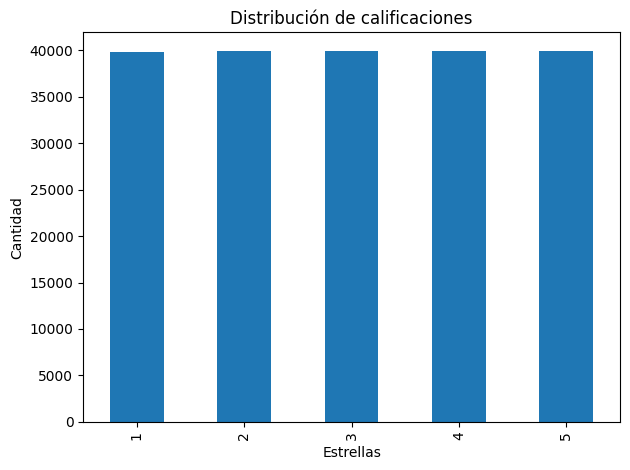

In [ ]:
# ============================================================
# 4.2 DISTRIBUCIÓN DE ESTRELLAS
# ============================================================

conteo_estrellas = df_train_raw["stars"].value_counts().sort_index()

display(conteo_estrellas.to_frame("cantidad"))

conteo_estrellas.plot(
    kind="bar",
    title="Distribución de calificaciones"
)
plt.xlabel("Estrellas")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

Cantidad de categorías: 30


,cantidad
product_category,
home,26908
wireless,25794
toy,13614
sports,13173
pc,11144
home_improvement,10906
electronics,10374
beauty,7333
automotive,7114


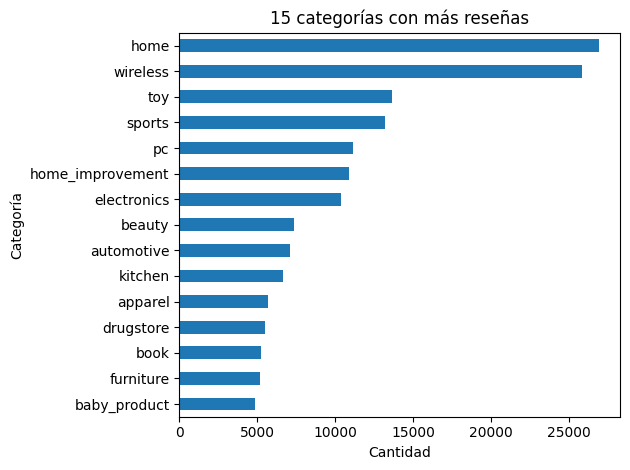

In [ ]:
# ============================================================
# 4.3 CATEGORÍAS DE PRODUCTO
# ============================================================

conteo_categorias = df_train_raw["product_category"].value_counts()

print("Cantidad de categorías:", df_train_raw["product_category"].nunique())
display(conteo_categorias.head(15).to_frame("cantidad"))

conteo_categorias.head(15).sort_values().plot(
    kind="barh",
    title="15 categorías con más reseñas"
)
plt.xlabel("Cantidad")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

,valor
count,199500.000000
mean,27.796536
std,24.171224
min,2.000000
25%,13.000000
50%,22.000000
75%,34.000000
max,551.000000


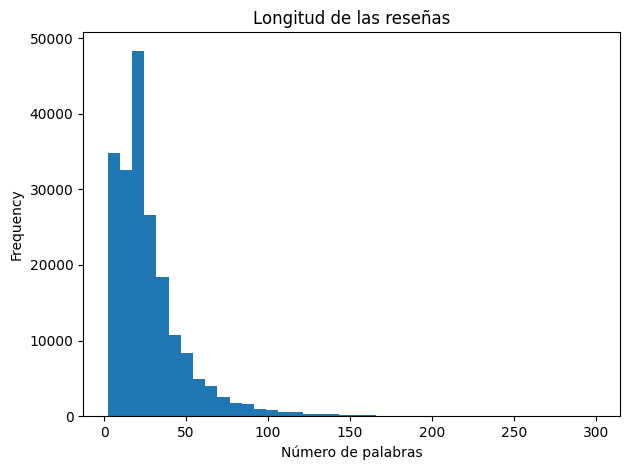

In [ ]:
# ============================================================
# 4.4 LONGITUD DE LAS RESEÑAS
# ============================================================

df_train_raw["n_palabras_body"] = (
    df_train_raw["review_body"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

display(df_train_raw["n_palabras_body"].describe().to_frame("valor"))

df_train_raw["n_palabras_body"].clip(upper=300).plot(
    kind="hist",
    bins=40,
    title="Longitud de las reseñas"
)
plt.xlabel("Número de palabras")
plt.tight_layout()
plt.show()

### Creación de la variable objetivo

Se combinan las estrellas en tres sentimientos. Después se toma una muestra balanceada para evitar que una clase domine el entrenamiento.

Puedes cambiar `N_POR_CLASE_TRAIN` según el tiempo disponible:

- `6000`: rápido;
- `12000`: recomendado;
- `20000`: más robusto, pero tarda más.

In [ ]:
# ============================================================
# 4.5 CREACIÓN DE SENTIMIENTO
# ============================================================

def crear_sentimiento(stars):
    # 1 y 2 estrellas: negativo.
    if stars in [1, 2]:
        return "negativo"

    # 3 estrellas: neutro.
    if stars == 3:
        return "neutro"

    # 4 y 5 estrellas: positivo.
    return "positivo"


for dataframe in [df_train_raw, df_val_raw, df_test_raw]:
    dataframe["sentimiento"] = dataframe["stars"].apply(crear_sentimiento)

print("Distribución de sentimiento en train:")
display(df_train_raw["sentimiento"].value_counts().to_frame("cantidad"))

Distribución de sentimiento en train:


,cantidad
sentimiento,
positivo,79862
negativo,79749
neutro,39889


In [ ]:
# ============================================================
# 4.6 MUESTREO BALANCEADO
# ============================================================

# Cantidad de ejemplos por clase para entrenamiento.
N_POR_CLASE_TRAIN = 12000

# Cantidad de ejemplos por clase para validación y prueba.
N_POR_CLASE_VAL = 1000
N_POR_CLASE_TEST = 1000

def muestra_balanceada(df, n_por_clase, semilla=SEED):
    """
    Toma la misma cantidad de registros de cada sentimiento.
    """
    partes = []

    for clase, grupo in df.groupby("sentimiento"):
        n = min(n_por_clase, len(grupo))
        partes.append(grupo.sample(n=n, random_state=semilla))

    return (
        pd.concat(partes)
        .sample(frac=1, random_state=semilla)
        .reset_index(drop=True)
    )

df_train = muestra_balanceada(df_train_raw, N_POR_CLASE_TRAIN)
df_val = muestra_balanceada(df_val_raw, N_POR_CLASE_VAL)
df_test = muestra_balanceada(df_test_raw, N_POR_CLASE_TEST)

print("Train balanceado:", df_train.shape)
print("Validation balanceado:", df_val.shape)
print("Test balanceado:", df_test.shape)

display(df_train["sentimiento"].value_counts().to_frame("cantidad"))
display(df_val["sentimiento"].value_counts().to_frame("cantidad"))
display(df_test["sentimiento"].value_counts().to_frame("cantidad"))

Train balanceado: (36000, 11)
Validation balanceado: (3000, 10)
Test balanceado: (3000, 10)


,cantidad
sentimiento,
neutro,12000
positivo,12000
negativo,12000


,cantidad
sentimiento,
neutro,1000
negativo,1000
positivo,1000


,cantidad
sentimiento,
neutro,1000
negativo,1000
positivo,1000


## 5. Preprocesamiento

El texto final combina:

- título de la reseña;
- cuerpo de la reseña.

Pipeline:

1. unir título y cuerpo;
2. pasar a minúsculas;
3. eliminar URL y correos;
4. normalizar tildes;
5. eliminar caracteres especiales;
6. reducir espacios;
7. eliminar palabras vacías;
8. conservar negaciones.

In [ ]:
# ============================================================
# 5.1 UNIÓN DE TÍTULO Y CUERPO
# ============================================================

def unir_titulo_cuerpo(df):
    """
    Crea una columna texto con el título y el cuerpo de la reseña.
    """
    titulo = df["review_title"].fillna("").astype(str).str.strip()
    cuerpo = df["review_body"].fillna("").astype(str).str.strip()

    df = df.copy()
    df["texto_original"] = (titulo + ". " + cuerpo).str.strip(". ")

    return df

df_train = unir_titulo_cuerpo(df_train)
df_val = unir_titulo_cuerpo(df_val)
df_test = unir_titulo_cuerpo(df_test)

display(df_train[["review_title", "review_body", "texto_original"]].head())

,review_title,review_body,texto_original
0,Robustez. Dificultad para sacar las tarjetas,Las gomas son demadiado duras. Cuesta bastante...,Robustez. Dificultad para sacar las tarjetas. ...
1,Correcto,Cumple su función. Por el día apenas se ven pe...,Correcto. Cumple su función. Por el día apenas...
2,Aceptable,"Está bien, lástima que a la persona q se la re...","Aceptable. Está bien, lástima que a la persona..."
3,Justo lo que necesitaba,"Justo lo que buscaba, una luz tenue para que d...","Justo lo que necesitaba. Justo lo que buscaba,..."
4,Gregorio Vicente,En tres meses de uso esporádico ya no funciona...,Gregorio Vicente. En tres meses de uso esporád...


In [ ]:
# ============================================================
# 5.2 FUNCIÓN DE LIMPIEZA
# ============================================================

# No incluimos "no", "nunca", "jamas" ni "sin" porque cambian el sentimiento.
STOPWORDS_ES = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "como",
    "con", "contra", "cual", "cuando", "de", "del", "desde", "donde",
    "durante", "e", "el", "ella", "ellas", "ellos", "en", "entre",
    "era", "eran", "eres", "es", "esa", "esas", "ese", "eso", "esos",
    "esta", "estaba", "estaban", "estado", "estamos", "estar", "estas",
    "este", "esto", "estos", "fue", "fueron", "ha", "han", "hasta",
    "hay", "la", "las", "le", "les", "lo", "los", "mas", "me", "mi",
    "mis", "muy", "nos", "o", "os", "para", "pero", "por", "porque",
    "que", "se", "ser", "si", "sobre", "su", "sus", "tambien", "te",
    "tenia", "tiene", "todo", "tu", "tus", "un", "una", "uno", "unos",
    "y", "ya"
}

def limpiar_texto(texto):
    """
    Preprocesa una reseña.
    """
    texto = str(texto).lower()

    # Eliminamos URL y correos.
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"\S+@\S+", " ", texto)

    # Normalizamos tildes.
    texto = unidecode(texto)

    # Conservamos letras y espacios.
    texto = re.sub(r"[^a-zñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    # Eliminamos stopwords.
    tokens = [
        palabra
        for palabra in texto.split()
        if palabra not in STOPWORDS_ES and len(palabra) > 1
    ]

    return " ".join(tokens)

In [ ]:
# ============================================================
# 5.3 APLICACIÓN DEL PREPROCESAMIENTO
# ============================================================

for dataframe in [df_train, df_val, df_test]:
    dataframe["texto_limpio"] = dataframe["texto_original"].apply(limpiar_texto)

# Eliminamos registros que hayan quedado vacíos.
df_train = df_train[df_train["texto_limpio"].str.len() > 0].reset_index(drop=True)
df_val = df_val[df_val["texto_limpio"].str.len() > 0].reset_index(drop=True)
df_test = df_test[df_test["texto_limpio"].str.len() > 0].reset_index(drop=True)

display(
    df_train[
        ["texto_original", "texto_limpio", "sentimiento"]
    ].head(10)
)

,texto_original,texto_limpio,sentimiento
0,Robustez. Dificultad para sacar las tarjetas. ...,robustez dificultad sacar tarjetas gomas son d...,neutro
1,Correcto. Cumple su función. Por el día apenas...,correcto cumple funcion dia apenas ven noche v...,neutro
2,"Aceptable. Está bien, lástima que a la persona...",aceptable bien lastima persona regale coloco p...,neutro
3,"Justo lo que necesitaba. Justo lo que buscaba,...",justo necesitaba justo buscaba luz tenue duerm...,positivo
4,Gregorio Vicente. En tres meses de uso esporád...,gregorio vicente tres meses uso esporadico no ...,negativo
5,Martillo perforador. El martillo va perfecto p...,martillo perforador martillo va perfecto funci...,negativo
6,No trabaja a la potencia indicada en la web. S...,no trabaja potencia indicada web trabaja no si...,negativo
7,Tamaño da bolsa. Me gusto por la calidad y pre...,tamano da bolsa gusto calidad precio tamano ad...,positivo
8,"No me convence. No repetiré, mucha marca pero ...",no convence no repetire mucha marca producto d...,neutro
9,No va bien y la mando de vuelta. El paquete pa...,no va bien mando vuelta paquete parece paquete...,negativo


## 6. Representación del texto

### 6.1 Bag of Words
Representa cada documento mediante conteos de palabras.

### 6.2 TF-IDF
Pondera los términos según su relevancia.

### 6.3 Embeddings
Word2Vec aprende vectores densos para las palabras.

In [ ]:
# ============================================================
# 6.1 BAG OF WORDS
# ============================================================

bow_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3
)

X_bow_train = bow_vectorizer.fit_transform(df_train["texto_limpio"])

print("Forma de Bag of Words:", X_bow_train.shape)
print("Primeros términos:")
print(bow_vectorizer.get_feature_names_out()[:30])

Forma de Bag of Words: (36000, 5000)
Primeros términos:
['abajo' 'abierta' 'abierto' 'abre' 'abren' 'abres' 'abri' 'abriga'
 'abril' 'abrir' 'abrir caja' 'abrir cerrar' 'abrir paquete' 'abrirlo'
 'absolutamente' 'absoluto' 'absorbe' 'aburrido' 'acaba' 'acabada'
 'acabado' 'acabado no' 'acabados' 'acabados son' 'acaban' 'acabar'
 'acabe' 'acabo' 'acabo recibir' 'acaso']


In [ ]:
# ============================================================
# 6.2 TF-IDF
# ============================================================

tfidf_exploratorio = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_tfidf_train = tfidf_exploratorio.fit_transform(df_train["texto_limpio"])

print("Forma de TF-IDF:", X_tfidf_train.shape)
print("Primeros términos:")
print(tfidf_exploratorio.get_feature_names_out()[:30])

Forma de TF-IDF: (36000, 8000)
Primeros términos:
['abajo' 'abajo no' 'abierta' 'abiertas' 'abierto' 'abierto no' 'abiertos'
 'abollada' 'abollado' 'abolladuras' 'abono' 'abra' 'abre' 'abren' 'abres'
 'abri' 'abriga' 'abrigo' 'abril' 'abrio' 'abrir' 'abrir caja'
 'abrir cerrar' 'abrir paquete' 'abrirla' 'abrirlo' 'abro' 'absoluta'
 'absolutamente' 'absolutamente nada']


In [ ]:
# ============================================================
# 6.3 EMBEDDINGS WORD2VEC
# ============================================================

oraciones = [
    texto.split()
    for texto in df_train["texto_limpio"]
]

word2vec_model = Word2Vec(
    sentences=oraciones,
    vector_size=100,
    window=5,
    min_count=3,
    workers=2,
    sg=1,
    epochs=15,
    seed=SEED
)

print("Tamaño del vocabulario:", len(word2vec_model.wv.index_to_key))

palabra_prueba = "calidad"

if palabra_prueba in word2vec_model.wv:
    display(
        pd.DataFrame(
            word2vec_model.wv.most_similar(palabra_prueba, topn=10),
            columns=["palabra", "similitud"]
        )
    )
else:
    print("La palabra de prueba no está en el vocabulario.")

Tamaño del vocabulario: 12301


,palabra,similitud
0,realcion,0.794012
1,indiscutible,0.723785
2,buna,0.722528
3,regulera,0.710788
4,extraordinaria,0.709312
5,sergio,0.708219
6,precii,0.700097
7,relaccion,0.699578
8,ostia,0.699254
9,replica,0.698450


## 7. Modelado de temas con LDA




In [ ]:

# ============================================================
# 7.1 PREPARACIÓN PARA LDA
# ============================================================

# Cantidad de temas.
N_TOPICS = 6

# Cantidad máxima de reseñas para LDA.
N_LDA_SAMPLE = min(20000, len(df_train))

# Primero crear la muestra para LDA.
df_lda = df_train.sample(
    n=N_LDA_SAMPLE,
    random_state=SEED
).copy()

# Stopwords adicionales que solamente se eliminarán para LDA.
STOPWORDS_LDA = STOPWORDS_ES.union({"producto","productos","amazon","bien","mucho","poco","hacer","hace","tener","queda","puede","estan","esta","son","cumple","dos","he","ni","solo","siempre","tambien","compra","comprar"})

def limpiar_para_lda(texto):
    """
    Aplica la limpieza general y elimina palabras
    adicionales que no ayudan a distinguir temas.
    """

    # Primero aplicar el preprocesamiento general.
    texto = limpiar_texto(texto)

    # Después eliminar stopwords específicas para LDA.
    tokens = [
        palabra
        for palabra in texto.split()
        if palabra not in STOPWORDS_LDA
    ]

    return " ".join(tokens)

# Ahora crear la columna dentro del nuevo df_lda.
df_lda["texto_lda"] = (
    df_lda["texto_original"]
    .apply(limpiar_para_lda)
)

# Eliminar posibles textos vacíos.
df_lda = (
    df_lda[df_lda["texto_lda"].str.len() > 0]
    .reset_index(drop=True)
)

# Crear el vectorizador.
lda_vectorizer = CountVectorizer(
    max_features=4000,
    min_df=5,
    max_df=0.90,
    ngram_range=(1, 1)
)

# Usar la nueva columna específica para LDA.
X_lda = lda_vectorizer.fit_transform(
    df_lda["texto_lda"]
)

print("Matriz LDA:", X_lda.shape)

# Comprobar que la columna exista.
display(
    df_lda[
        ["texto_original", "texto_limpio", "texto_lda"]
    ].head()
)

Matriz LDA: (20000, 4000)


,texto_original,texto_limpio,texto_lda
0,Buen artículo. El artículo llegó en perfectas ...,buen articulo articulo llego perfectas condici...,buen articulo articulo llego perfectas condici...
1,No lo sé de momento. están bien se pueden usar ??,no momento estan bien pueden usar,no momento pueden usar
2,Buena compra. Lo que esperaba. Perfecta para i...,buena compra esperaba perfecta ir piscina gimn...,buena esperaba perfecta ir piscina gimnasio et...
3,Estafa. No me ha llegado el producto y no hay ...,estafa no llegado producto no forma contactar ...,estafa no llegado no forma contactar vendedor ...
4,No tiene funcionalidad. Es de MUY MALA CALIDAD...,no funcionalidad mala calidad separacion tiras...,no funcionalidad mala calidad separacion tiras...


In [ ]:
# ============================================================
# 7.2 ENTRENAMIENTO DE LDA
# ============================================================

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    learning_method="batch",
    random_state=SEED,
    n_jobs=-1
)

lda_model.fit(X_lda)

def obtener_tabla_temas(modelo, vectorizador, n_palabras=12):
    """
    Devuelve las palabras principales de cada tema.
    """
    vocabulario = vectorizador.get_feature_names_out()
    filas = []

    for numero_tema, pesos in enumerate(modelo.components_):
        indices = pesos.argsort()[-n_palabras:][::-1]
        palabras = [vocabulario[i] for i in indices]

        filas.append({
            "tema": numero_tema,
            "palabras_principales": ", ".join(palabras)
        })

    return pd.DataFrame(filas)

tabla_temas = obtener_tabla_temas(
    lda_model,
    lda_vectorizer
)

display(tabla_temas)

tabla_temas.to_csv(
    RESULTS_DIR / "temas_lda.csv",
    index=False,
    encoding="utf-8"
)

,tema,palabras_principales
0,0,"perfecto, facil, no, correcto, buen, buena, pr..."
1,1,"calidad, precio, buena, no, buen, mala, relaci..."
2,2,"no, pantalla, funda, buen, bastante, movil, pa..."
3,3,"no, funciona, nada, bateria, sin, uso, va, car..."
4,4,"no, llego, llegado, sin, caja, mal, vendedor, ..."
5,5,"no, grande, pequeno, demasiado, tamano, color,..."


Primeras reseñas con su tema asignado:


,texto_original,tema_lda,nombre_tema,prob_tema
0,Buen artículo. El artículo llegó en perfectas ...,4,Entrega y proceso de envío,0.915875
1,No lo sé de momento. están bien se pueden usar ??,0,Facilidad de uso y satisfacción general,0.518720
2,Buena compra. Lo que esperaba. Perfecta para i...,5,"Diseño, tamaño y apariencia",0.427739
3,Estafa. No me ha llegado el producto y no hay ...,4,Entrega y proceso de envío,0.944126
4,No tiene funcionalidad. Es de MUY MALA CALIDAD...,3,Funcionamiento y rendimiento técnico,0.377156


Cantidad de reseñas por tema:


,cantidad
nombre_tema,
Funcionamiento y rendimiento técnico,4926
Entrega y proceso de envío,3479
Calidad y relación calidad-precio,3194
"Diseño, tamaño y apariencia",3055
Accesorios y protección del producto,2931
Facilidad de uso y satisfacción general,2415


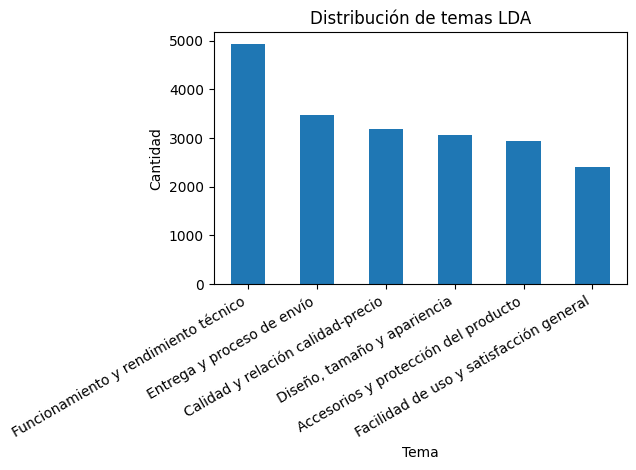

In [ ]:
# ============================================================
# 7.3 ASIGNACIÓN DE TEMAS
# ============================================================

NOMBRES_TEMAS = {
    0: "Facilidad de uso y satisfacción general",
    1: "Calidad y relación calidad-precio",
    2: "Accesorios y protección del producto",
    3: "Funcionamiento y rendimiento técnico",
    4: "Entrega y proceso de envío",
    5: "Diseño, tamaño y apariencia"
}

# Calcular la distribución de probabilidad de temas para cada reseña.

distribucion_temas = lda_model.transform(X_lda)

df_lda = df_lda.copy()

# Tema con mayor probabilidad.
df_lda["tema_lda"] = distribucion_temas.argmax(axis=1)

# Nombre del tema.
df_lda["nombre_tema"] = df_lda["tema_lda"].map(NOMBRES_TEMAS)

# Probabilidad del tema asignado.
df_lda["prob_tema"] = distribucion_temas.max(axis=1)

print("Primeras reseñas con su tema asignado:")

display(
    df_lda[
        ["texto_original",
         "tema_lda",
         "nombre_tema",
         "prob_tema"]
    ].head()
)

print("Cantidad de reseñas por tema:")

display(
    df_lda["nombre_tema"]
    .value_counts()
    .to_frame("cantidad")
)

df_lda["nombre_tema"].value_counts().plot(
    kind="bar",
    title="Distribución de temas LDA"
)

plt.xlabel("Tema")
plt.ylabel("Cantidad")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 8. Modelo clásico: Naive Bayes

Se utilizará `MultinomialNB` con TF-IDF.

El vectorizador se ajusta únicamente con entrenamiento para evitar fuga de información.

In [ ]:
# ============================================================
# 8.1 VARIABLES PARA NAIVE BAYES
# ============================================================

X_train_text = df_train["texto_limpio"]
X_val_text = df_val["texto_limpio"]
X_test_text = df_test["texto_limpio"]

y_train = df_train["sentimiento"]
y_val = df_val["sentimiento"]
y_test = df_test["sentimiento"]

tfidf_nb = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_train_nb = tfidf_nb.fit_transform(X_train_text)
X_val_nb = tfidf_nb.transform(X_val_text)
X_test_nb = tfidf_nb.transform(X_test_text)

print("Train TF-IDF:", X_train_nb.shape)
print("Validation TF-IDF:", X_val_nb.shape)
print("Test TF-IDF:", X_test_nb.shape)

Train TF-IDF: (36000, 15000)
Validation TF-IDF: (3000, 15000)
Test TF-IDF: (3000, 15000)


In [ ]:
# ============================================================
# 8.2 ENTRENAMIENTO DE NAIVE BAYES
# ============================================================

modelo_nb = MultinomialNB(alpha=0.5)
modelo_nb.fit(X_train_nb, y_train)

pred_val_nb = modelo_nb.predict(X_val_nb)
pred_test_nb = modelo_nb.predict(X_test_nb)

print("Resultados de validación:")
print(classification_report(y_val, pred_val_nb, digits=4))

print("Resultados de prueba:")
print(classification_report(y_test, pred_test_nb, digits=4))

Resultados de validación:
              precision    recall  f1-score   support

    negativo     0.7219    0.7140    0.7179      1000
      neutro     0.5699    0.5750    0.5724      1000
    positivo     0.7804    0.7820    0.7812      1000

    accuracy                         0.6903      3000
   macro avg     0.6908    0.6903    0.6905      3000
weighted avg     0.6908    0.6903    0.6905      3000

Resultados de prueba:
              precision    recall  f1-score   support

    negativo     0.7137    0.7330    0.7232      1000
      neutro     0.5670    0.5840    0.5754      1000
    positivo     0.7837    0.7390    0.7607      1000

    accuracy                         0.6853      3000
   macro avg     0.6881    0.6853    0.6864      3000
weighted avg     0.6881    0.6853    0.6864      3000



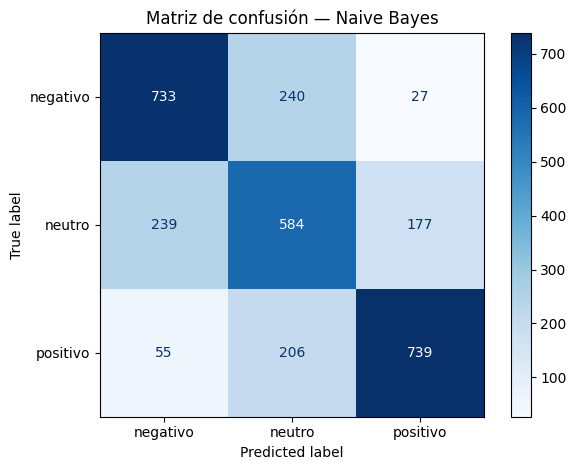

In [ ]:
# ============================================================
# 8.3 MATRIZ DE CONFUSIÓN DE NAIVE BAYES
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_test_nb,
    cmap="Blues",
    values_format="d"
)
plt.title("Matriz de confusión — Naive Bayes")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "matriz_confusion_naive_bayes.png",
    dpi=150
)
plt.show()

## 9. Modelo neuronal: LSTM

La red utiliza:

1. tokenización;
2. secuencias;
3. padding;
4. capa de embeddings;
5. LSTM bidireccional;
6. capas densas;
7. salida multiclase.

`EarlyStopping` evita entrenar innecesariamente cuando la validación deja de mejorar.

In [ ]:
# ============================================================
# 9.1 CODIFICACIÓN DE ETIQUETAS
# ============================================================

label_encoder = LabelEncoder()

y_train_lstm = label_encoder.fit_transform(y_train)
y_val_lstm = label_encoder.transform(y_val)
y_test_lstm = label_encoder.transform(y_test)

print("Clases:", list(label_encoder.classes_))

Clases: ['negativo', 'neutro', 'positivo']


In [ ]:
# ============================================================
# 9.2 TOKENIZACIÓN Y PADDING
# ============================================================

MAX_WORDS = 20000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

seq_train = tokenizer.texts_to_sequences(X_train_text)
seq_val = tokenizer.texts_to_sequences(X_val_text)
seq_test = tokenizer.texts_to_sequences(X_test_text)

# Elegimos la longitud correspondiente al percentil 95.
longitudes = [len(secuencia) for secuencia in seq_train]
MAX_LEN = max(int(np.percentile(longitudes, 95)), 20)

X_train_pad = pad_sequences(
    seq_train,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    seq_val,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    seq_test,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("MAX_LEN:", MAX_LEN)
print("Train:", X_train_pad.shape)
print("Validation:", X_val_pad.shape)
print("Test:", X_test_pad.shape)

MAX_LEN: 41
Train: (36000, 41)
Validation: (3000, 41)
Test: (3000, 41)


In [ ]:
# ============================================================
# 9.3 CONSTRUCCIÓN DEL MODELO LSTM
# ============================================================

VOCAB_SIZE = min(
    MAX_WORDS,
    len(tokenizer.word_index) + 1
)

N_CLASSES = len(label_encoder.classes_)

modelo_lstm = keras.Sequential([
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=96,
        mask_zero=True
    ),
    layers.Bidirectional(
        layers.LSTM(
            64,
        dropout=0.25
        )
    ),
    layers.Dropout(0.35),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(
        N_CLASSES,
        activation="softmax"
    )
])

modelo_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 9.4 ENTRENAMIENTO DE LA LSTM
# ============================================================

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]

historial = modelo_lstm.fit(
    X_train_pad,
    y_train_lstm,
    validation_data=(X_val_pad, y_val_lstm),
    epochs=12,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
563/563 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.6522 - loss: 0.7515 - val_accuracy: 0.6923 - val_loss: 0.6772 - learning_rate: 0.0010
Epoch 2/12
563/563 ━━━━━━━━━━━━━━━━━━━━ 76s 135ms/step - accuracy: 0.7467 - loss: 0.5905 - val_accuracy: 0.6830 - val_loss: 0.7054 - learning_rate: 0.0010
Epoch 3/12
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.7940 - loss: 0.5029
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
563/563 ━━━━━━━━━━━━━━━━━━━━ 81s 133ms/step - accuracy: 0.8070 - loss: 0.4832 - val_accuracy: 0.6693 - val_loss: 0.7951 - learning_rate: 0.0010
Epoch 4/12
563/563 ━━━━━━━━━━━━━━━━━━━━ 72s 127ms/step - accuracy: 0.8635 - loss: 0.3488 - val_accuracy: 0.6577 - val_loss: 0.9516 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


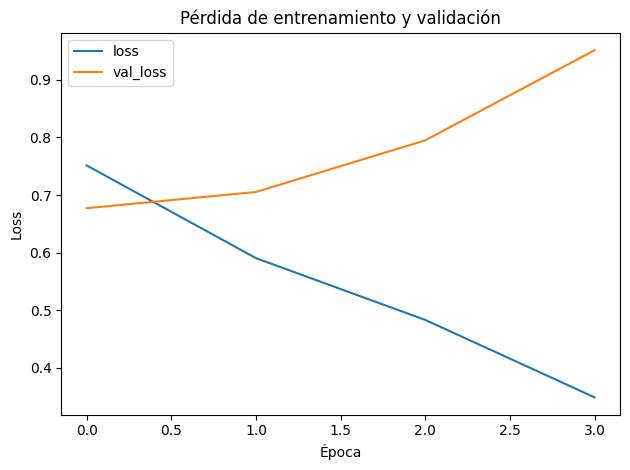

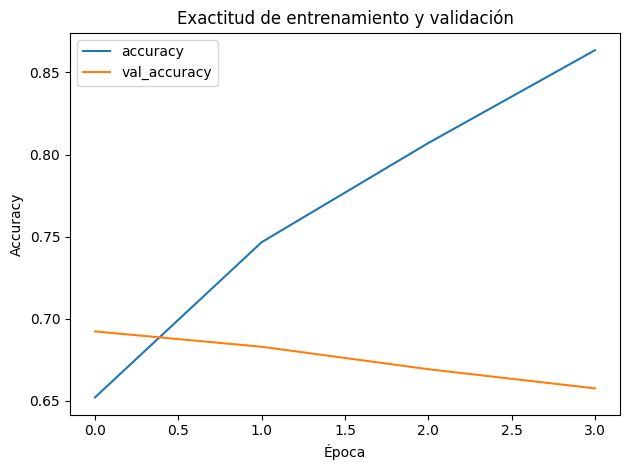

In [ ]:
# ============================================================
# 9.5 CURVAS DE ENTRENAMIENTO
# ============================================================

hist_df = pd.DataFrame(historial.history)

hist_df[["loss", "val_loss"]].plot(
    title="Pérdida de entrenamiento y validación"
)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "curva_loss_lstm.png",
    dpi=150
)
plt.show()

hist_df[["accuracy", "val_accuracy"]].plot(
    title="Exactitud de entrenamiento y validación"
)
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "curva_accuracy_lstm.png",
    dpi=150
)
plt.show()

              precision    recall  f1-score   support

    negativo     0.7269    0.7720    0.7488      1000
      neutro     0.5755    0.5410    0.5577      1000
    positivo     0.7715    0.7700    0.7708      1000

    accuracy                         0.6943      3000
   macro avg     0.6913    0.6943    0.6924      3000
weighted avg     0.6913    0.6943    0.6924      3000



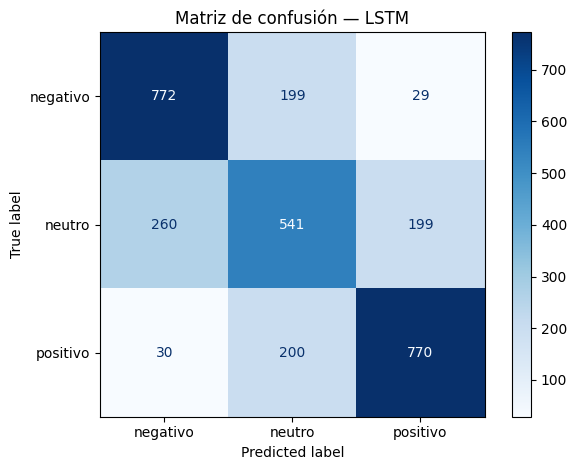

In [ ]:
# ============================================================
# 9.6 EVALUACIÓN DE LA LSTM
# ============================================================

proba_test_lstm = modelo_lstm.predict(
    X_test_pad,
    verbose=0
)

pred_test_lstm_num = proba_test_lstm.argmax(axis=1)

pred_test_lstm = label_encoder.inverse_transform(
    pred_test_lstm_num
)

print(classification_report(
    y_test,
    pred_test_lstm,
    digits=4
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_test_lstm,
    cmap="Blues",
    values_format="d"
)
plt.title("Matriz de confusión — LSTM")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "matriz_confusion_lstm.png",
    dpi=150
)
plt.show()

## 10. Comparación de resultados

In [ ]:
# ============================================================
# 10.1 FUNCIÓN DE MÉTRICAS
# ============================================================

def calcular_metricas(y_real, y_pred, modelo):
    """
    Calcula accuracy, precision, recall y F1 macro.
    """
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_real,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "modelo": modelo,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }


resultados = pd.DataFrame([
    calcular_metricas(
        y_test,
        pred_test_nb,
        "Naive Bayes"
    ),
    calcular_metricas(
        y_test,
        pred_test_lstm,
        "LSTM"
    )
])

display(
    resultados.sort_values(
        "f1_macro",
        ascending=False
    )
)

resultados.to_csv(
    RESULTS_DIR / "comparacion_modelos.csv",
    index=False,
    encoding="utf-8"
)

,modelo,accuracy,precision_macro,recall_macro,f1_macro
1,LSTM,0.694333,0.691335,0.694333,0.692430
0,Naive Bayes,0.685333,0.688130,0.685333,0.686428


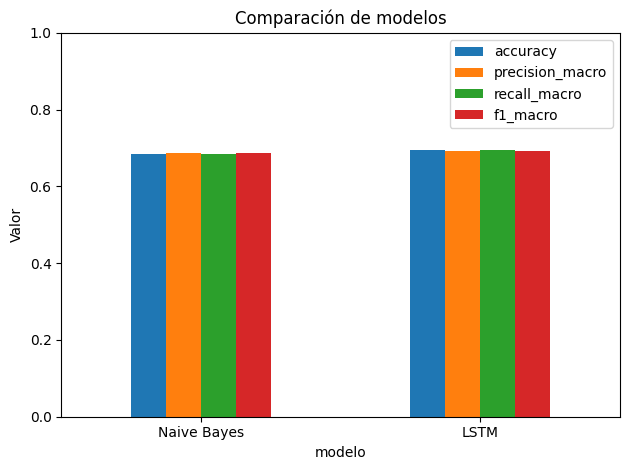

In [ ]:
# ============================================================
# 10.2 GRÁFICO COMPARATIVO
# ============================================================

resultados.set_index("modelo")[
    [
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ]
].plot(
    kind="bar",
    ylim=(0, 1),
    title="Comparación de modelos"
)

plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "comparacion_modelos.png",
    dpi=150
)
plt.show()

## 11. Detección de aspectos

Se utiliza un diccionario de palabras clave para identificar:

- precio;
- calidad;
- entrega;
- empaque;
- funcionamiento;
- durabilidad;
- atención;
- diseño;
- facilidad de uso;
- tamaño.

Este enfoque es interpretable y se puede ampliar fácilmente.

In [ ]:
# ============================================================
# 11. DETECCIÓN DE ASPECTOS
# ============================================================

ASPECTOS = {
    "precio": [
        "precio", "caro", "cara", "barato", "barata",
        "coste", "costo", "economico", "oferta",
        "calidad precio"
    ],
    "calidad": [
        "calidad", "bueno", "buena", "malo", "mala",
        "excelente", "pesimo", "defectuoso", "original",
        "material"
    ],
    "entrega": [
        "entrega", "envio", "llego", "llegar", "tarde",
        "rapido", "rapida", "retraso", "recibi",
        "transportista"
    ],
    "empaque": [
        "caja", "embalaje", "empaque", "paquete",
        "envuelto", "roto", "abierto", "proteccion"
    ],
    "funcionamiento": [
        "funciona", "funcionar", "fallo", "falla",
        "enciende", "apaga", "bateria", "carga",
        "rendimiento"
    ],
    "durabilidad": [
        "duradero", "duradera", "dura", "rompio",
        "rompe", "meses", "resistente", "fragil",
        "desgaste"
    ],
    "atencion": [
        "atencion", "servicio", "vendedor", "respuesta",
        "devolucion", "garantia", "soporte", "reembolso"
    ],
    "diseno": [
        "diseno", "bonito", "bonita", "color",
        "estetica", "apariencia", "modelo"
    ],
    "facilidad_uso": [
        "facil", "dificil", "sencillo", "sencilla",
        "usar", "instalar", "manejar", "practico",
        "comodo"
    ],
    "tamano": [
        "tamano", "grande", "pequeno", "pequena",
        "medida", "ajusta", "corto", "larga"
    ]
}

def detectar_aspectos(texto):
    """
    Devuelve los aspectos detectados mediante palabras clave.
    """
    texto_normalizado = limpiar_texto(texto)
    encontrados = []

    for aspecto, palabras in ASPECTOS.items():
        for palabra in palabras:
            palabra_normalizada = limpiar_texto(palabra)

            if palabra_normalizada in texto_normalizado:
                encontrados.append(aspecto)
                break

    return encontrados if encontrados else ["sin aspecto específico"]


ejemplo_aspectos = (
    "El producto funciona bien, pero llegó tarde "
    "y la caja estaba rota."
)

print(detectar_aspectos(ejemplo_aspectos))

['entrega', 'empaque', 'funcionamiento']


## Guardado de modelos y objetos

Esta celda guarda todo lo necesario para usar Gradio sin volver a entrenar.

In [ ]:
# ============================================================
# GUARDADO DE MODELOS
# ============================================================

# Naive Bayes y TF-IDF.
joblib.dump(
    modelo_nb,
    MODELS_DIR / "modelo_naive_bayes.joblib"
)

joblib.dump(
    tfidf_nb,
    MODELS_DIR / "vectorizador_tfidf.joblib"
)

# LDA y vectorizador.
joblib.dump(
    lda_model,
    MODELS_DIR / "modelo_lda.joblib"
)

joblib.dump(
    lda_vectorizer,
    MODELS_DIR / "vectorizador_lda.joblib"
)

# LabelEncoder.
joblib.dump(
    label_encoder,
    MODELS_DIR / "label_encoder.joblib"
)

# Tokenizer.
with open(
    MODELS_DIR / "tokenizer.json",
    "w",
    encoding="utf-8"
) as archivo:
    archivo.write(tokenizer.to_json())

# Modelo LSTM.
modelo_lstm.save(
    MODELS_DIR / "modelo_lstm.keras"
)

# Word2Vec.
word2vec_model.save(
    str(MODELS_DIR / "word2vec.model")
)

# Configuración general.
config = {
    "dataset_name": DATASET_NAME,
    "max_len": int(MAX_LEN),
    "max_words": int(MAX_WORDS),
    "n_topics": int(N_TOPICS),
    "clases": label_encoder.classes_.tolist(),
    "seed": int(SEED)
}

with open(
    MODELS_DIR / "config.json",
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        config,
        archivo,
        ensure_ascii=False,
        indent=2
    )

# Diccionario de aspectos.
with open(
    MODELS_DIR / "aspectos.json",
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        ASPECTOS,
        archivo,
        ensure_ascii=False,
        indent=2
    )

# Palabras principales de los temas.
tabla_temas.to_json(
    MODELS_DIR / "temas_lda.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("Archivos guardados en:", MODELS_DIR)

for archivo in sorted(MODELS_DIR.iterdir()):
    print("-", archivo.name)

Archivos guardados en: /content/drive/MyDrive/Proyecto_PLN_Amazon/modelos
- aspectos.json
- config.json
- label_encoder.joblib
- modelo_lda.joblib
- modelo_lstm.keras
- modelo_naive_bayes.joblib
- temas_lda.json
- tokenizer.json
- vectorizador_lda.joblib
- vectorizador_tfidf.joblib
- word2vec.model


# PARTE B — CARGA DE MODELOS, GRADIO Y DEMO

En una nueva sesión de Colab no debes ejecutar nuevamente el entrenamiento.

Ejecuta solamente las celdas de esta parte.

## 12. Interfaz Gradio

In [1]:
# ============================================================
# PARTE B.1 — INSTALACIÓN E IMPORTACIÓN MÍNIMA
# ============================================================

!pip -q install gradio unidecode

import re
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from unidecode import unidecode

from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import tokenizer_from_json

import gradio as gr

from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Proyecto_PLN_Amazon"
)

MODELS_DIR = PROJECT_DIR / "modelos"

print("Carpeta de modelos:", MODELS_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 18.7 MB/s eta 0:00:00
Mounted at /content/drive
Carpeta de modelos: /content/drive/MyDrive/Proyecto_PLN_Amazon/modelos


In [2]:
# ============================================================
# PARTE B.2 — MISMO PREPROCESAMIENTO DEL ENTRENAMIENTO
# ============================================================

STOPWORDS_ES = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "como",
    "con", "contra", "cual", "cuando", "de", "del", "desde", "donde",
    "durante", "e", "el", "ella", "ellas", "ellos", "en", "entre",
    "era", "eran", "eres", "es", "esa", "esas", "ese", "eso", "esos",
    "esta", "estaba", "estaban", "estado", "estamos", "estar", "estas",
    "este", "esto", "estos", "fue", "fueron", "ha", "han", "hasta",
    "hay", "la", "las", "le", "les", "lo", "los", "mas", "me", "mi",
    "mis", "muy", "nos", "o", "os", "para", "pero", "por", "porque",
    "que", "se", "ser", "si", "sobre", "su", "sus", "tambien", "te",
    "tenia", "tiene", "todo", "tu", "tus", "un", "una", "uno", "unos",
    "y", "ya"
}

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"\S+@\S+", " ", texto)
    texto = unidecode(texto)
    texto = re.sub(r"[^a-zñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    tokens = [
        palabra
        for palabra in texto.split()
        if palabra not in STOPWORDS_ES and len(palabra) > 1
    ]

    return " ".join(tokens)

In [3]:
# ============================================================
# PARTE B.3 — CARGA DE MODELOS
# ============================================================

modelo_nb_demo = joblib.load(
    MODELS_DIR / "modelo_naive_bayes.joblib"
)

tfidf_demo = joblib.load(
    MODELS_DIR / "vectorizador_tfidf.joblib"
)

lda_demo = joblib.load(
    MODELS_DIR / "modelo_lda.joblib"
)

lda_vectorizer_demo = joblib.load(
    MODELS_DIR / "vectorizador_lda.joblib"
)

label_encoder_demo = joblib.load(
    MODELS_DIR / "label_encoder.joblib"
)

with open(
    MODELS_DIR / "tokenizer.json",
    "r",
    encoding="utf-8"
) as archivo:
    tokenizer_demo = tokenizer_from_json(
        archivo.read()
    )

with open(
    MODELS_DIR / "config.json",
    "r",
    encoding="utf-8"
) as archivo:
    config_demo = json.load(archivo)

with open(
    MODELS_DIR / "aspectos.json",
    "r",
    encoding="utf-8"
) as archivo:
    ASPECTOS_DEMO = json.load(archivo)

with open(
    MODELS_DIR / "temas_lda.json",
    "r",
    encoding="utf-8"
) as archivo:
    TEMAS_DEMO = json.load(archivo)

MAX_LEN_DEMO = int(
    config_demo["max_len"]
)

modelo_lstm_demo = keras.models.load_model(
    MODELS_DIR / "modelo_lstm.keras"
)

print("Modelos cargados correctamente.")
print("Clases:", label_encoder_demo.classes_)
print("MAX_LEN:", MAX_LEN_DEMO)

Modelos cargados correctamente.
Clases: ['negativo' 'neutro' 'positivo']
MAX_LEN: 41


In [4]:
# ============================================================
# PARTE B.4 — FUNCIONES DE PREDICCIÓN
# ============================================================

# Nombres interpretados manualmente a partir de las palabras
# principales obtenidas con LDA.
NOMBRES_TEMAS = {
    0: "Facilidad de uso y satisfacción general",
    1: "Calidad y relación calidad-precio",
    2: "Accesorios y protección del producto",
    3: "Funcionamiento y rendimiento técnico",
    4: "Entrega y proceso de envío",
    5: "Diseño, tamaño y apariencia"
}


def detectar_aspectos_demo(texto):
    """
    Detecta aspectos mediante el diccionario de palabras clave.
    """
    texto_normalizado = limpiar_texto(texto)
    encontrados = []

    for aspecto, palabras in ASPECTOS_DEMO.items():
        for palabra in palabras:
            palabra_normalizada = limpiar_texto(palabra)

            if palabra_normalizada in texto_normalizado:
                encontrados.append(aspecto)
                break

    return encontrados if encontrados else ["sin aspecto específico"]


def predecir_naive_bayes(texto_limpio):
    """
    Predice sentimiento y probabilidades con Naive Bayes.
    """
    vector = tfidf_demo.transform([texto_limpio])
    probabilidades = modelo_nb_demo.predict_proba(vector)[0]
    clases = modelo_nb_demo.classes_
    indice = int(np.argmax(probabilidades))

    return (
        clases[indice],
        {
            clase: float(probabilidad)
            for clase, probabilidad in zip(clases, probabilidades)
        }
    )


def predecir_lstm(texto_limpio):
    """
    Predice sentimiento y probabilidades con LSTM.
    """
    secuencia = tokenizer_demo.texts_to_sequences([texto_limpio])

    secuencia_pad = pad_sequences(
        secuencia,
        maxlen=MAX_LEN_DEMO,
        padding="post",
        truncating="post"
    )

    probabilidades = modelo_lstm_demo.predict(
        secuencia_pad,
        verbose=0
    )[0]

    indice = int(np.argmax(probabilidades))

    etiqueta = label_encoder_demo.inverse_transform(
        [indice]
    )[0]

    return (
        etiqueta,
        {
            clase: float(probabilidad)
            for clase, probabilidad
            in zip(label_encoder_demo.classes_, probabilidades)
        }
    )


def predecir_tema(texto_limpio):
    """
    Predice el tema principal mediante LDA.
    """
    vector = lda_vectorizer_demo.transform([texto_limpio])
    distribucion = lda_demo.transform(vector)[0]

    tema = int(np.argmax(distribucion))
    probabilidad = float(np.max(distribucion))

    palabras = next(
        (
            item["palabras_principales"]
            for item in TEMAS_DEMO
            if int(item["tema"]) == tema
        ),
        "Sin palabras disponibles"
    )

    nombre_tema = NOMBRES_TEMAS.get(
        tema,
        f"Tema {tema}"
    )

    return tema, nombre_tema, probabilidad, palabras


def analizar_resena(texto):
    """
    Función principal utilizada por la interfaz Gradio.

    Devuelve exactamente 8 resultados, en el mismo orden
    configurado en boton.click().
    """
    if texto is None or not str(texto).strip():
        return (
            "### ⚠️ Escribe una reseña para comenzar.",
            {},
            "",
            {},
            "",
            "### Tema principal\n\nSin información.",
            "### Aspectos detectados\n\nSin información.",
            ""
        )

    texto_limpio = limpiar_texto(texto)

    if not texto_limpio:
        return (
            "### ⚠️ El texto no contiene palabras suficientes.",
            {},
            "",
            {},
            "",
            "### Tema principal\n\nTexto insuficiente.",
            "### Aspectos detectados\n\nSin información.",
            texto_limpio
        )

    # Predicciones de sentimiento.
    etiqueta_nb, proba_nb = predecir_naive_bayes(texto_limpio)
    etiqueta_lstm, proba_lstm = predecir_lstm(texto_limpio)

    # Predicción del tema.
    _, nombre_tema, prob_tema, palabras_tema = predecir_tema(
        texto_limpio
    )

    # Detección de aspectos.
    aspectos = detectar_aspectos_demo(texto)

    # La LSTM se presenta como resultado principal porque obtuvo
    # el mejor F1 macro en la comparación final.
    confianza_lstm = max(proba_lstm.values())

    resumen = (
        f"## {etiqueta_lstm.capitalize()}\n\n"
        f"**Confianza del modelo LSTM:** {confianza_lstm:.1%}"
    )

    tema_markdown = (
        f"## Tema principal\n\n"
        f"### **{nombre_tema}**\n\n"
        f"**Confianza del tema:** {prob_tema:.1%}\n\n"
        f"**Palabras principales:** {palabras_tema}"
    )

    aspectos_visibles = " · ".join(
        f"**{aspecto.replace('_', ' ').title()}**"
        for aspecto in aspectos
    )

    aspectos_markdown = (
        f"## Aspectos detectados\n\n"
        f"### {aspectos_visibles}"
    )

    return (
        resumen,
        proba_nb,
        etiqueta_nb.capitalize(),
        proba_lstm,
        etiqueta_lstm.capitalize(),
        tema_markdown,
        aspectos_markdown,
        texto_limpio
    )


def limpiar_interfaz():
    """
    Limpia los nueve componentes configurados en el botón Limpiar.
    """
    return (
        "",   # entrada
        "Escribe una reseña y presiona **Analizar reseña**.",  # resumen
        {},   # probabilidades NB
        "",   # predicción NB
        {},   # probabilidades LSTM
        "",   # predicción LSTM
        "## Tema principal\n\nEsperando una reseña.",  # tema
        "## Aspectos detectados\n\nEsperando una reseña.",  # aspectos
        ""    # texto limpio
    )

In [ ]:
# ============================================================
# PARTE B.5 — CREACIÓN DE LA INTERFAZ GRADIO
# ============================================================

ejemplos = [
    ["Excelente producto. Llegó rápido, bien empacado y funciona perfectamente."],
    ["No funciona. La batería se descarga en pocos minutos y quiero devolverlo."],
    ["El producto es aceptable, pero esperaba mejor calidad por ese precio."],
    ["La caja llegó rota, aunque el producto funciona bien."],
    ["Es bonito y fácil de usar, pero tardó demasiado en llegar."]
]

CSS = """
.gradio-container {
    max-width: 1180px !important;
    margin: 0 auto !important;
}

.hero {
    text-align: center;
    padding: 18px 10px 8px 10px;
}

.hero h1 {
    margin-bottom: 6px;
}

.card {
    border: 1px solid #e5e7eb !important;
    border-radius: 16px !important;
    padding: 16px !important;
    background: white !important;
}

#resultado-principal {
    border-left: 6px solid #6366f1;
    border-radius: 12px;
    padding: 14px 18px;
    background: #f8fafc;
}

#tema-principal {
    border: 1px solid #dbeafe;
    border-left: 7px solid #2563eb;
    border-radius: 16px;
    padding: 22px;
    background: #f8fbff;
    min-height: 210px;
}

#tema-principal h2 {
    font-size: 26px !important;
    font-weight: 800 !important;
    margin-bottom: 14px !important;
}

#tema-principal h3 {
    font-size: 22px !important;
    font-weight: 800 !important;
    color: #1e3a8a !important;
    line-height: 1.35 !important;
}

#aspectos-principales {
    border: 1px solid #ddd6fe;
    border-left: 7px solid #7c3aed;
    border-radius: 16px;
    padding: 22px;
    background: #faf8ff;
    min-height: 210px;
}

#aspectos-principales h2 {
    font-size: 26px !important;
    font-weight: 800 !important;
    margin-bottom: 20px !important;
}

#aspectos-principales h3 {
    font-size: 20px !important;
    font-weight: 800 !important;
    color: #5b21b6 !important;
    line-height: 1.8 !important;
}
"""

with gr.Blocks(
    title="Voz del cliente — Amazon",
    css=CSS
) as demo:

    # --------------------------------------------------------
    # ENCABEZADO
    # --------------------------------------------------------
    gr.Markdown(
        """
        <div class="hero">
            <h1>🛍️ Análisis de la voz del cliente</h1>
            <p>
                Clasificación de sentimiento, detección de aspectos
                y modelado de temas en reseñas de productos.
            </p>
        </div>
        """
    )

    # --------------------------------------------------------
    # ENTRADA Y RESULTADO PRINCIPAL
    # --------------------------------------------------------
    with gr.Row():

        with gr.Column(scale=6, elem_classes="card"):

            gr.Markdown("### ✍️ Escribe una reseña")

            entrada = gr.Textbox(
                label="Reseña del producto",
                lines=7,
                placeholder=(
                    "Ejemplo: El producto funciona bien, "
                    "pero llegó tarde y la caja estaba rota."
                )
            )

            with gr.Row():
                boton = gr.Button(
                    "🔎 Analizar reseña",
                    variant="primary"
                )

                boton_limpiar = gr.Button(
                    "Limpiar"
                )

            gr.Examples(
                examples=ejemplos,
                inputs=entrada,
                label="Pruebas rápidas"
            )

        with gr.Column(scale=4, elem_classes="card"):

            gr.Markdown("### 📌 Resultado principal")

            resumen = gr.Markdown(
                "Escribe una reseña y presiona **Analizar reseña**.",
                elem_id="resultado-principal"
            )

            gr.Markdown(
                """
                ### ⚙️ Pipeline utilizado

                1. **Preprocesamiento:** limpieza y normalización
                2. **Representación:** TF-IDF y secuencias
                3. **Clasificación:** Naive Bayes y LSTM
                4. **Interpretación:** LDA y aspectos
                """
            )

    # --------------------------------------------------------
    # COMPARACIÓN DE MODELOS
    # --------------------------------------------------------
    gr.Markdown("## 📊 Comparación de modelos")

    with gr.Row():

        with gr.Column(elem_classes="card"):

            salida_nb = gr.Textbox(
                label="Predicción — Naive Bayes",
                interactive=False
            )

            prob_nb = gr.Label(
                label="Probabilidades — Naive Bayes",
                num_top_classes=3
            )

        with gr.Column(elem_classes="card"):

            salida_lstm = gr.Textbox(
                label="Predicción — LSTM",
                interactive=False
            )

            prob_lstm = gr.Label(
                label="Probabilidades — LSTM",
                num_top_classes=3
            )

    # --------------------------------------------------------
    # INTERPRETACIÓN
    # --------------------------------------------------------
    gr.Markdown("## 🧩 Interpretación de la reseña")

    with gr.Row():

        with gr.Column(scale=6):
            salida_tema = gr.Markdown(
                "## Tema principal\n\nEsperando una reseña.",
                elem_id="tema-principal"
            )

        with gr.Column(scale=4):
            salida_aspectos = gr.Markdown(
                "## Aspectos detectados\n\nEsperando una reseña.",
                elem_id="aspectos-principales"
            )

    # --------------------------------------------------------
    # TEXTO PREPROCESADO
    # --------------------------------------------------------
    with gr.Accordion(
        "Ver texto preprocesado",
        open=False
    ):
        salida_limpia = gr.Textbox(
            label="Texto limpio",
            interactive=False
        )

    # --------------------------------------------------------
    # EVENTOS
    # --------------------------------------------------------
    boton.click(
        fn=analizar_resena,
        inputs=[entrada],
        outputs=[
            resumen,
            prob_nb,
            salida_nb,
            prob_lstm,
            salida_lstm,
            salida_tema,
            salida_aspectos,
            salida_limpia
        ]
    )

    boton_limpiar.click(
        fn=limpiar_interfaz,
        inputs=[],
        outputs=[
            entrada,
            resumen,
            prob_nb,
            salida_nb,
            prob_lstm,
            salida_lstm,
            salida_tema,
            salida_aspectos,
            salida_limpia
        ]
    )

# ============================================================
# LANZAMIENTO
# ============================================================

demo.launch(
    share=True,
    debug=True
)

/tmp/ipykernel_864/447455275.py:87: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://340df294c55ddb9dee.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/di

## 13. Conclusiones


* El proceso de limpieza del texto permitió normalizar las reseñas mediante la conversión a minúsculas, eliminación de caracteres especiales, números, signos de puntuación y palabras vacías (stopwords), conservando únicamente la información relevante para el análisis.

* El algoritmo Latent Dirichlet Allocation (LDA) identificó seis temas predominantes dentro de las reseñas, correspondientes principalmente a:

  * Funcionamiento y rendimiento técnico.
  * Entrega y proceso de envío.
  * Calidad y relación calidad-precio.
  * Diseño, tamaño y apariencia.
  * Accesorios y protección del producto.
  * Facilidad de uso y satisfacción general.

* Se comparó un modelo clásico (Naive Bayes) con un modelo basado en redes neuronales recurrentes (LSTM). La red neuronal LSTM obtuvo el mejor desempeño, superando ligeramente a Naive Bayes tanto en exactitud como en F1 Macro.
| Modelo      | Accuracy   | F1 Macro   |
| ----------- | ---------- | ---------- |
| Naive Bayes | **0.6853** | **0.6864** |
| LSTM        | **0.6943** | **0.6924** |

* Durante el entrenamiento de la LSTM se observó un incremento continuo de la exactitud sobre el conjunto de entrenamiento, mientras que el desempeño sobre el conjunto de validación comenzó a disminuir a partir de las primeras épocas, indicando la presencia de **sobreajuste (overfitting)**. Para controlar este comportamiento se emplearon las técnicas de **Early Stopping** y **ReduceLROnPlateau**, las cuales permitieron detener automáticamente el entrenamiento y restaurar los pesos correspondientes al mejor modelo encontrado, mejorando la capacidad de generalización.

* Finalmente, se desarrolló una interfaz interactiva mediante Gradio, capaz de analizar nuevas reseñas ingresadas por el usuario en tiempo real.

El proyecto permitió integrar exitosamente diferentes técnicas de Procesamiento del Lenguaje Natural, desde el preprocesamiento y la representación del texto hasta el modelado de temas, la clasificación de sentimientos y el despliegue de una aplicación interactiva. Los resultados obtenidos muestran que la combinación de modelos clásicos y redes neuronales constituye una estrategia efectiva para analizar reseñas de productos en español, proporcionando información útil sobre el sentimiento de los clientes, los aspectos más mencionados y los temas predominantes. Asimismo, la interfaz desarrollada demuestra el potencial de estas herramientas para apoyar procesos de análisis de opiniones en escenarios reales de comercio electrónico.



